In [1]:
import sys; sys.path.insert(0, "..")
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
from pathlib import Path

from scaling.io import load_results

# Use LaTeX-like font (Computer Modern)
matplotlib.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "CMU Serif", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 12,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
})

SAVE_DIR = Path("figures/cbn_unif_mixture")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
df = load_results("results/2026-04-03_12h05_cbn_unif_mixture/results.csv")

df10 = df[df.n_vars == 10]
df20 = df[df.n_vars == 20]

In [3]:
GENERATOR_NAME = "cbn_unif_mixture"

# Mapping from column name to (graph_type, metric) for filename
FILENAME_MAP = {
    "time_s": ("time",),
    "SHD": ("cpdags", "shd"),
    "F1-Score": ("cpdags", "f1"),
    "TPR": ("cpdags", "tpr"),
    "SHD_skeleton": ("skeletons", "shd"),
    "F1-Score_skeleton": ("skeletons", "f1"),
    "TPR_skeleton": ("skeletons", "tpr"),
}

def plot_single(data, y, ylabel, n_vars, show_legend=False):
    """Plot a single metric for one n_vars subset and save as PNG."""
    fig, ax = plt.subplots(figsize=(5, 3.5))
    sns.lineplot(
        data=data, x="n_samples", y=y, hue="algo",
        errorbar="se", marker="o", ax=ax,
    )
    ax.set_xlabel("Number of samples")
    ax.set_ylabel(ylabel)
    if show_legend:
        ax.legend(title=None, frameon=True)
    else:
        ax.get_legend().remove()
    fig.tight_layout()
    parts = FILENAME_MAP[y]
    if len(parts) == 1:
        filename = f"{GENERATOR_NAME}_{n_vars}v_{parts[0]}.png"
    else:
        filename = f"{GENERATOR_NAME}_{n_vars}v_{parts[0]}_{parts[1]}.png"
    fig.savefig(SAVE_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

## 10 variables

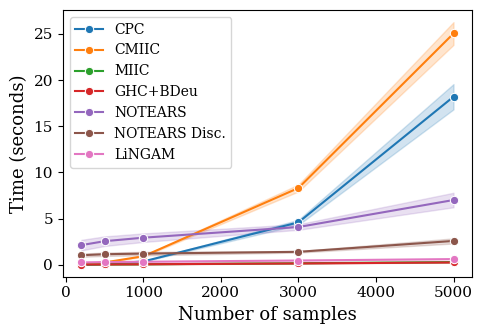

In [4]:
plot_single(df10, "time_s", "Time (seconds)", n_vars=10, show_legend=True)

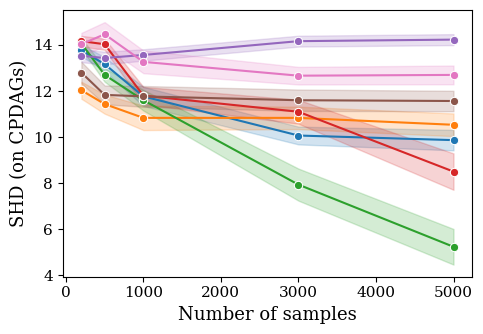

In [5]:
plot_single(df10, "SHD", "SHD (on CPDAGs)", n_vars=10)

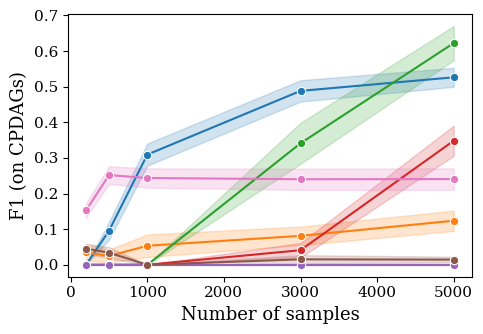

In [6]:
plot_single(df10, "F1-Score", "F1 (on CPDAGs)", n_vars=10)

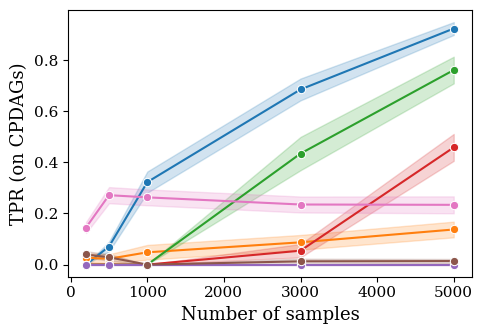

In [7]:
plot_single(df10, "TPR", "TPR (on CPDAGs)", n_vars=10)

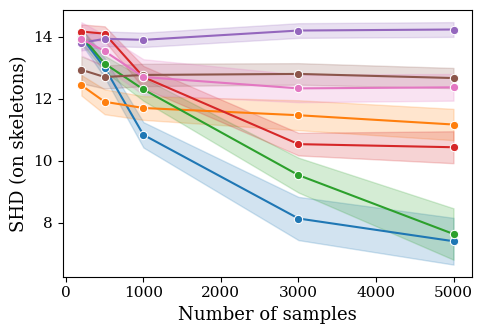

In [8]:
plot_single(df10, "SHD_skeleton", "SHD (on skeletons)", n_vars=10)

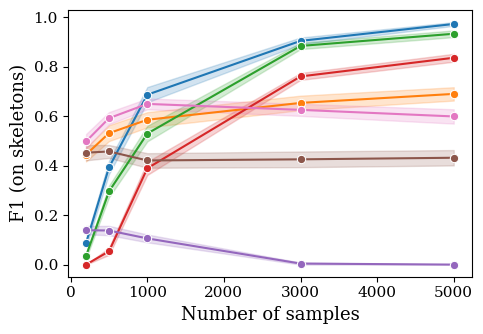

In [9]:
plot_single(df10, "F1-Score_skeleton", "F1 (on skeletons)", n_vars=10)

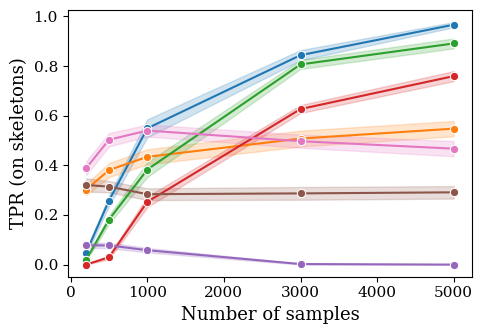

In [10]:
plot_single(df10, "TPR_skeleton", "TPR (on skeletons)", n_vars=10)

## 20 variables

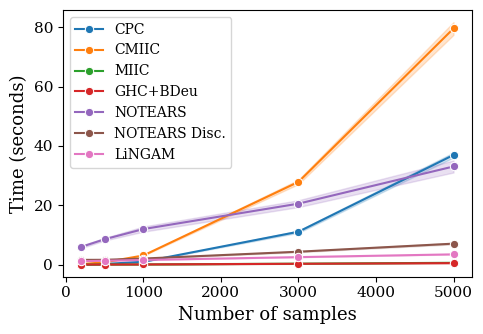

In [11]:
plot_single(df20, "time_s", "Time (seconds)", n_vars=20, show_legend=True)

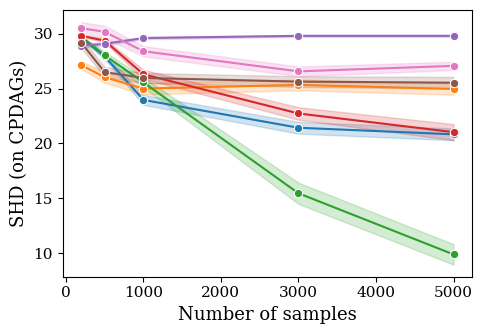

In [12]:
plot_single(df20, "SHD", "SHD (on CPDAGs)", n_vars=20)

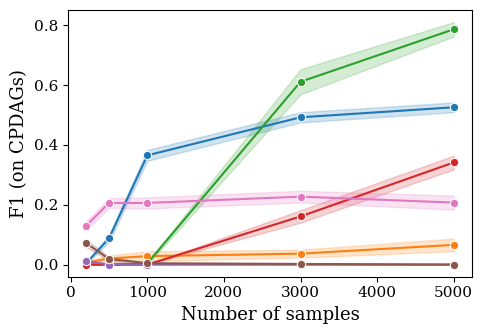

In [13]:
plot_single(df20, "F1-Score", "F1 (on CPDAGs)", n_vars=20)

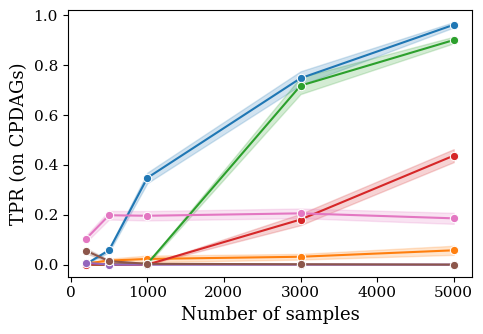

In [14]:
plot_single(df20, "TPR", "TPR (on CPDAGs)", n_vars=20)

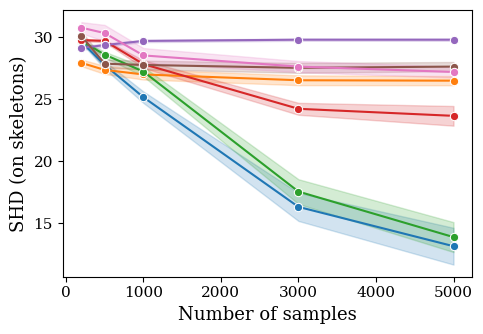

In [15]:
plot_single(df20, "SHD_skeleton", "SHD (on skeletons)", n_vars=20)

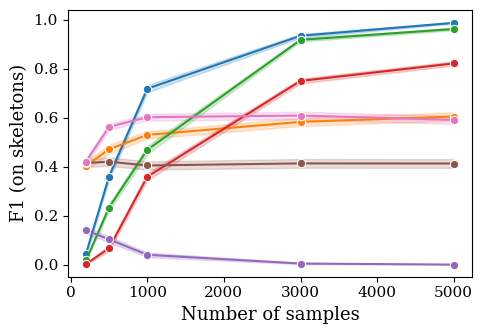

In [16]:
plot_single(df20, "F1-Score_skeleton", "F1 (on skeletons)", n_vars=20)

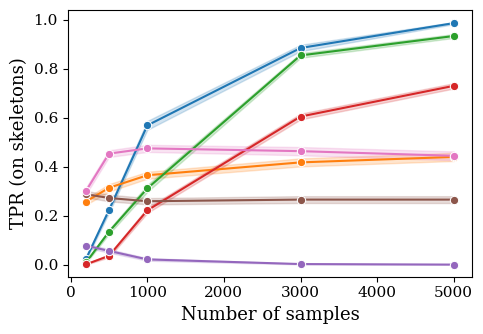

In [17]:
plot_single(df20, "TPR_skeleton", "TPR (on skeletons)", n_vars=20)